In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt

In [150]:
pantries = pd.read_csv("pantries_old.csv")
gdf_pantry = gpd.GeoDataFrame(pantries,geometry=gpd.points_from_xy(pantries.Long, pantries.Lat),crs="EPSG:4326").to_crs(32618)
blocks = pd.read_csv("blocks.csv")
gdf_blocks = gpd.GeoDataFrame(blocks, geometry=gpd.points_from_xy(blocks.lon, blocks.lat), crs="EPSG:4326").to_crs(32618)

In [151]:
pantry_ids = gdf_pantry["Pantry"].tolist()

# Normalize lot size (acres)
gdf_pantry["lot_norm"] = gdf_pantry["lot_acres"] / gdf_pantry["lot_acres"].mean()


In [152]:
decay_rate = 0.765  # 23.5% drop per mile

def decay(d_miles):
    return decay_rate ** d_miles

alpha = 1.0   # decay influence
beta  = 0.4   # lot size influence (tunable)

for pid in pantry_ids:
    pantry_row = gdf_pantry.loc[gdf_pantry["Pantry"] == pid].iloc[0]
    pantry_point = pantry_row.geometry
    lot_norm = pantry_row["lot_norm"]

    # distance in miles from each block to this pantry
    distances = gdf_blocks.geometry.distance(pantry_point) / 1609.34

    # distance decay
    D_ij = decay(distances)

    # attractiveness = distance decay * normalized lot size
    gdf_blocks[f"A_{pid}"] = (D_ij ** alpha) * (lot_norm ** beta)


In [153]:
A_cols = [f"A_{pid}" for pid in pantry_ids]
A_sum = gdf_blocks[A_cols].sum(axis=1)

for pid in pantry_ids:
    gdf_blocks[f"P_{pid}"] = gdf_blocks[f"A_{pid}"] / A_sum


In [154]:
# convert to fraction 0–1 if needed
if gdf_blocks["poverty_rate_est"].max() > 1.5:  # crude check
    gdf_blocks["poverty_frac"] = gdf_blocks["poverty_rate_est"] / 100.0
else:
    gdf_blocks["poverty_frac"] = gdf_blocks["poverty_rate_est"]

for pid in pantry_ids:
    gdf_blocks[f"demand_{pid}"] = gdf_blocks["poverty_frac"] * gdf_blocks[f"P_{pid}"]


In [155]:
pantry_demand = {
    pid: gdf_blocks[f"demand_{pid}"].sum()
    for pid in pantry_ids
}
print(pantry_demand)


{'Tompkins Community Action': 58.829721790425346, 'St. Johns Community Services Pantry': 23.598381885985795, 'Ithaca Free Clinic': 41.614429289377014, 'Salvation Army SK- Ithaca Saturday FP': 50.5368375535175, 'Immaculate Conception Food Pantry': 47.41510064569035, 'Baptized Church of Jesus Christ': 32.701938819838624, 'Enfield Food Distribution': 16.691291511579614, 'Ithaca Kitchen Cupboard': 50.37529850358577}


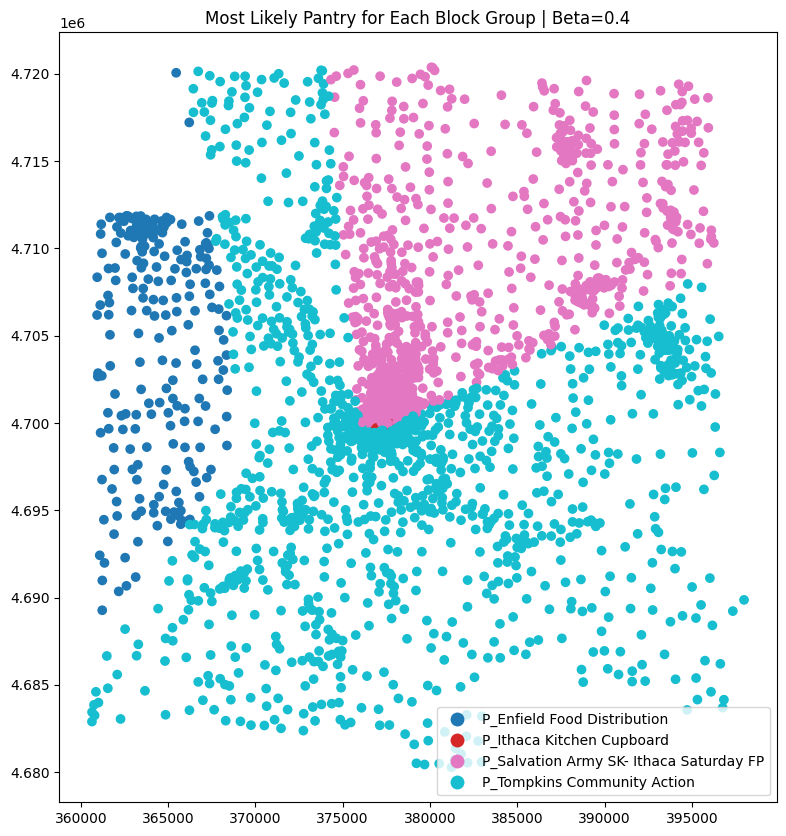

In [156]:
gdf_blocks["best_pantry"] = gdf_blocks[[f"P_{pid}" for pid in pantry_ids]].idxmax(axis=1)
# gdf_blocks["best_pantry"] = gdf_blocks["best_pantry"].str.extract("(\d+)").astype(int)

gdf_blocks.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    figsize=(10, 10)
)
plt.title(f"Most Likely Pantry for Each Block Group | Beta={beta}")
plt.show()
 

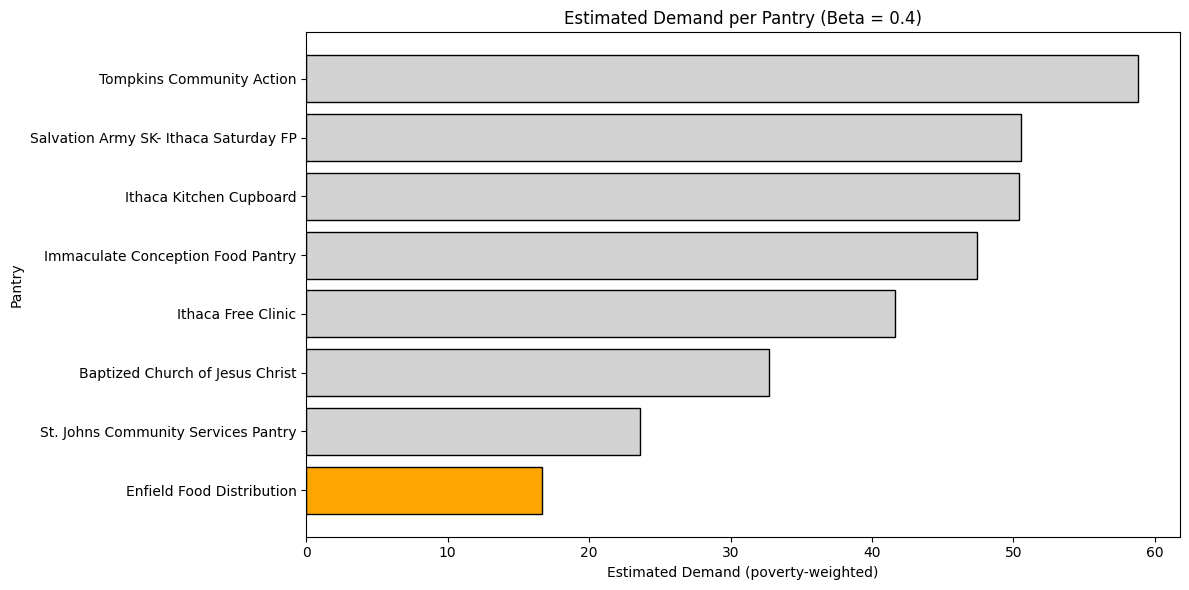

In [157]:
sorted_items = sorted(pantry_demand.items(), key=lambda kv: kv[1], reverse=True)
pantry_names = [name for name, val in sorted_items]
demand_values = [val for name, val in sorted_items]

highlight_name1 = "Enfield Food Distribution"
highlight_name2 = "NEW Enfield Food Distribution"

# Define colors: highlighted = accent color, others = neutral
colors = [
    "orange" if name == highlight_name1 or name == highlight_name2 else "lightgray"
    for name in pantry_names
]

plt.figure(figsize=(12, 6))
plt.barh(pantry_names, demand_values, color=colors, edgecolor="black")
plt.xlabel("Estimated Demand (poverty-weighted)")
plt.ylabel("Pantry")
plt.title(f"Estimated Demand per Pantry (Beta = {beta})")
plt.gca().invert_yaxis()  # optional: largest on top
plt.tight_layout()
plt.show()